<a href="https://colab.research.google.com/github/patidarparagi286-svg/machine-learning-concepts/blob/main/Loan_approval_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
#import matplotlib.pyplot as plt
#import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer  #for filling the missing values
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

In [ ]:
from google.colab import files
uploaded= files.upload()
filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)

Saving loan_approval.csv to loan_approval.csv


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Gender             500 non-null    object
 1   Married            500 non-null    object
 2   Dependents         500 non-null    object
 3   Education          500 non-null    object
 4   Self_Employed      500 non-null    object
 5   ApplicantIncome    500 non-null    int64 
 6   CoapplicantIncome  500 non-null    int64 
 7   LoanAmount         500 non-null    int64 
 8   Loan_Amount_Term   500 non-null    int64 
 9   Credit_History     500 non-null    int64 
 10  Property_Area      500 non-null    object
 11  Loan_Status        500 non-null    int64 
dtypes: int64(6), object(6)
memory usage: 47.0+ KB


In [ ]:
TARGET = "Loan_Status"       #1=approved

In [ ]:
print("missing value" ,df.isnull().sum())
print("\nhead" , df.head())
print("\ntail",df.tail())

missing value Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

head    Gender Married Dependents  ... Credit_History Property_Area  Loan_Status
0  Female     Yes         3+  ...              0         Urban            0
1    Male      No          0  ...              0     Semiurban            0
2  Female      No         3+  ...              1         Urban            1
3  Female     Yes          0  ...              1     Semiurban            1
4  Female      No          0  ...              1         Urban            0

[5 rows x 12 columns]

tail      Gender Married Dependents  ... Credit_History Property_Area  Loan_Status
495  Female     Yes         3+  ...              1         Urban            1
496  Female     Yes          0  ...              1

In [ ]:
print("\n---Target distribution(ratio)---")     #for checking the balancing of dataset
print(df[TARGET].value_counts(normalize=True).rename("ratio"))    #normalize=True--> means value in precentage


---Target distribution(ratio)---
Loan_Status
1    0.534
0    0.466
Name: ratio, dtype: float64


In [ ]:
import matplotlib.pyplot as plt  #graph
import seaborn as sns

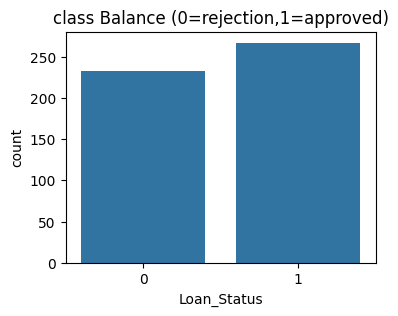

In [ ]:
plt.figure(figsize=(4,3))
sns.countplot(x=TARGET, data=df)
plt.title("class Balance (0=rejection,1=approved)")
plt.show()

In [ ]:
X=df.drop(columns=TARGET)
y=df[TARGET]



In [ ]:
#auto detect column types
num_features = X.select_dtypes(include=["number"]).columns.tolist()
print('\nNUMERIC FEATURES', num_features)

cat_features = X.select_dtypes(exclude=["number"]).columns.tolist()
print('\nCATEGORICAL FEATURES', cat_features)



NUMERIC FEATURES ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History']

CATEGORICAL FEATURES ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area']


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
num_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())  #standard_scaler-->data ko rande m lane ke liye
])

cat_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
    ('num', num_pipeline, num_features),
    ('cat', cat_pipeline, cat_features)
],remainder='drop'
)

In [ ]:
#MODEL
rf=RandomForestClassifier(
    n_estimators=200,
    random_state=42
    )


In [ ]:
pipe=Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', rf)
])

In [ ]:
pipe

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['ApplicantIncome',
                                                   'CoapplicantIncome',
                                                   'LoanAmount',
                                                   'Loan_Amount_Term',
                                                   'Credit_History']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Gender', 'Married',
                                                   'Dependents', 'Education',
                                                   'Self_Employed',
                                                   'Property_Area'])])),
                ('classifier',
                 RandomForestClassifier(n_estimators=200, random_state=42))])

In [ ]:
pipe.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['ApplicantIncome',
                                                   'CoapplicantIncome',
                                                   'LoanAmount',
                                                   'Loan_Amount_Term',
                                                   'Credit_History']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Gender', 'Married',
                                                   'Dependents', 'Education',
                                                   'Self_Employed',
                                                   'Property_Area'])])),
                ('classifier',
                 RandomForestClassifier(n_estimators=200, random_state=42))])

In [ ]:
from sklearn.metrics import accuracy_score
y_pred = pipe.predict(X_test)
print(accuracy_score(y_test, y_pred))

0.58
